In [11]:
import pandas as pd
import os

csv_path = '/kaggle/input/competitions/airbus-ship-detection/train_ship_segmentations_v2.csv'

df = pd.read_csv(csv_path)

display(df.head())

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [12]:
df["HasShip"] = df["EncodedPixels"].notnull().astype(int)
ships_per_image = df.groupby("ImageId")["HasShip"].sum().reset_index()
ships_per_image.columns = ["ImageId", "TotalShips"]

empty_images = (ships_per_image["TotalShips"] == 0).sum()
ship_images = (ships_per_image["TotalShips"] > 0).sum()

print(f"Total number of images: {len(ships_per_image)}")
print(f"Number of empty images: {empty_images}")
print(f"Number of images with at least one ship: {ship_images}")

Total number of images: 192556
Number of empty images: 150000
Number of images with at least one ship: 42556


In [13]:
df_ships = ships_per_image[ships_per_image["TotalShips"] > 0]
ship_counts = df_ships["TotalShips"].value_counts().sort_index()

print("Number of ships per image: ")
print(ship_counts) 

Number of ships per image: 
TotalShips
1     27104
2      7674
3      2954
4      1622
5       925
6       657
7       406
8       318
9       243
10      168
11      144
12      124
13       75
14       76
15       66
Name: count, dtype: int64


In [14]:
df_ships = df.dropna(subset = ["EncodedPixels"]).copy()
df_ships["ShipArea"] = df_ships["EncodedPixels"].apply(lambda x: sum([int(length) for length in x.split()[1::2]]))

print(f"Minimum ship area: {df_ships["ShipArea"].min()} pixels")
print(f"Maximum ship area: {df_ships["ShipArea"].max()} pixels")
print(f"Average Ship Area: {int(df_ships['ShipArea'].mean())} pixels")

Minimum ship area: 2 pixels
Maximum ship area: 25904 pixels
Average Ship Area: 1567 pixels


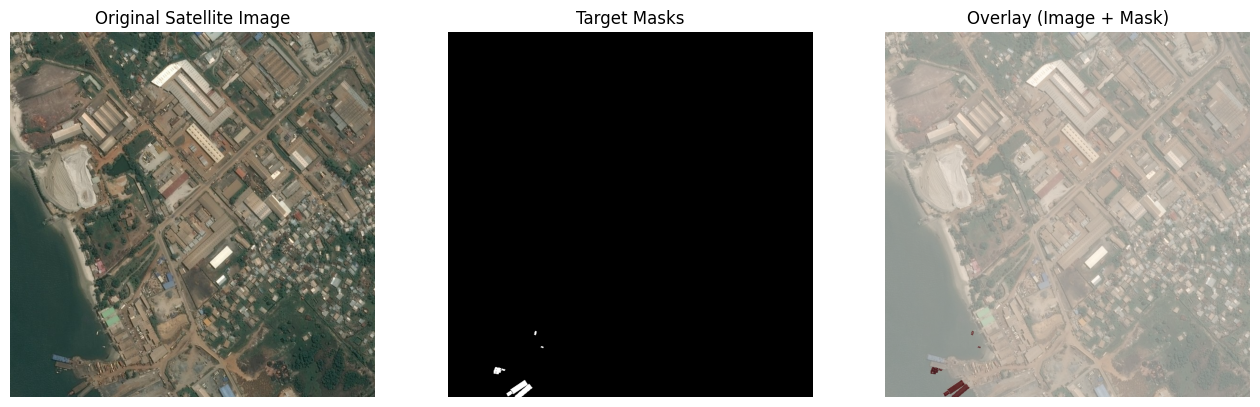

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

def rle_decode(mask_rle, shape = (768, 768)):
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype = int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype = np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T

def get_mask(image_id, dataframe):
    rle_list = dataframe[dataframe["ImageId"] == image_id]["EncodedPixels"].tolist()
    all_masks = np.zeros((768, 768))
    for rle in rle_list:
        if pd.notna(rle):
            all_masks += rle_decode(rle)
    return all_masks

train_img_dir = '/kaggle/input/competitions/airbus-ship-detection/train_v2'
sample_image_id = df_ships["ImageId"].iloc[10]
img_path = os.path.join(train_img_dir, sample_image_id)

img = imread(img_path)
mask = get_mask(sample_image_id, df)

fig, ax = plt.subplots(1,3,figsize = (16,5))

ax[0].imshow(img)
ax[0].set_title('Original Satellite Image')
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Target Masks')
ax[1].axis('off')

ax[2].imshow(img)
ax[2].imshow(mask, cmap='Reds', alpha=0.5) 
ax[2].set_title('Overlay (Image + Mask)')
ax[2].axis('off')

plt.show()

In [16]:
unique_ship_images = df_ships["ImageId"].unique()
df_positive_unique = pd.DataFrame({"ImageId": unique_ship_images})

df_empty = df[df["EncodedPixels"].isna()].copy()
df_empty = df_empty.drop_duplicates(subset = ["ImageId"])

num_ships = len(df_positive_unique)
df_empty_sampled = df_empty.sample(n = num_ships, random_state = 42)

print(f"Number of images with ships: {num_ships}")
print(f"Number of balanced empty images: {len(df_empty_sampled)}")


Number of images with ships: 42556
Number of balanced empty images: 42556


In [17]:
df_balanced = pd.concat([df_positive_unique, df_empty_sampled], ignore_index = True)
df_balanced = df_balanced.sample(frac = 1, random_state = 42).reset_index(drop = True)

print(f"Total balanced dataset size: {len(df_balanced)}")

Total balanced dataset size: 85112


In [18]:
import numpy as np
import tensorflow as tf
import os
import cv2
from tensorflow.keras.utils import Sequence

img_height = 256
img_width = 256
batch_size = 16
train_img_dir = "/kaggle/input/competitions/airbus-ship-detection/train_v2"

class AirbusDataGenerator(Sequence):
    def __init__(self, dataframe, image_dir, batch_size = 16, img_size = (256, 256), shuffle = True):
        self.df = dataframe
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.img_size = img_size  
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()

    def on_epoch_end(self):
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indexes]
    
        x = np.empty((self.batch_size, self.img_size[0], self.img_size[1], 3), dtype = np.float32)
        y = np.empty((self.batch_size, self.img_size[0], self.img_size[1], 1), dtype = np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            image_id = row["ImageId"]
            img_path = os.path.join(self.image_dir, image_id)

            img = imread(img_path)
            img_resized = tf.image.resize(img, self.img_size).numpy() / 255.0
            
            mask = get_mask(image_id, df)

            mask_expanded = np.expand_dims(mask, axis = -1)
            mask_resized = tf.image.resize(mask_expanded, self.img_size).numpy()

            x[i] = img_resized
            y[i] = mask_resized

        return x, y

In [19]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_balanced, test_size = 0.2, random_state = 42)

train_generator = AirbusDataGenerator(
    dataframe = train_df,
    image_dir = train_img_dir,
    batch_size = 16,
    img_size = (256, 256),
    shuffle = True
)

x_batch, y_batch = train_generator[0]

print(f"x_batch size: {x_batch.shape}")
print(f"y_batch size: {y_batch.shape}")

I0000 00:00:1786449952.344268      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786449952.347092      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


x_batch size: (16, 256, 256, 3)
y_batch size: (16, 256, 256, 1)


In [20]:
import tensorflow.keras.backend as K 

def dice_coef(y_true, y_pred, smooth = 1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam



def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    u4 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = concatenate([u4, c2]) 
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

    u5 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = concatenate([u5, c1]) 
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(u5)
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


model = build_unet()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, "accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 128, 128,  │      8,224 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     18,464 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 256, 256,  │      2,064 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │      4,624 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d_8[0][0]  

 Total params: 117,041 (457.19 KB)

 Trainable params: 117,041 (457.19 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
val_generator = AirbusDataGenerator(
    dataframe = val_df,
    image_dir = train_img_dir,
    batch_size = 16,
    img_size = (256, 256),
    shuffle = False
)

print("2 epoch starting..")

history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 2
)

2 epoch starting..


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2


2026-08-11 12:06:04.117140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:06:04.260702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:06:06.653275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:06:06.948607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:06:07.674534: E external/local_xla/xla/stream_

KeyboardInterrupt: 

In [23]:
!pip install segmentation_models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.6 MB/s eta 0:00:00


In [24]:
os.environ["SM_FRAMEWORK"] = "tf.keras"
import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [25]:
backbone = "resnet34"

model = sm.Unet(
    backbone_name = backbone,
    encoder_weights = "imagenet",
    classes = 1,
    activation = "sigmoid"
)

model.summary()

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, None,      │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, None,      │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, None,      │      9,408 │ zero_padding2d[0… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, None,      │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, None,      │          0 │ bn0[0][0]         │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, None,      │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, None,      │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, None,      │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, None,      │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, None,      │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, None,      │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, None,      │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, None,      │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, None,      │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, None,      │      4,096 │ stage1_unit1_rel

 Total params: 24,456,154 (93.29 MB)

 Trainable params: 24,438,804 (93.23 MB)

 Non-trainable params: 17,350 (67.77 KB)

In [27]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate = 0.001)

loss = sm.losses.bce_jaccard_loss

metrics = [sm.metrics.IOUScore(threshold = 0.5)]

model.compile(
    optimizer = optimizer,
    loss = loss,
    metrics = metrics
)

In [50]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath = "best_resnet34_unet_epoch_{epoch:02d}_iou_{val_iou_score:.4f}.keras",
    monitor =  "val_iou_score",
    mode = "max",
    save_best_only = True,
    verbose = 1
)

early_stop = EarlyStopping(
    monitor = "val_iou_score",
    mode = "max",
    patience = 4,
    verbose = 1,
    restore_best_weights = True
)

callbacks_list = [checkpoint, early_stop]

In [51]:
print("Training of the ResNet34-backboned model is starting..")

history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 30,
    steps_per_epoch = 1000,
    validation_steps = 200,
    callbacks = callbacks_list
)

Training of the ResNet34-backboned model is starting..
Epoch 1/30


2026-08-11 12:41:56.963435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:41:57.289566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:41:58.014977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:41:58.199286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-11 12:42:02.737067: E external/local_xla/xla/stream_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - iou_score: 0.2786 - loss: 0.8027

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_iou_score improved from None to 0.33018, saving model to best_resnet34_unet_epoch_01_iou_0.3302.keras

Epoch 1: finished saving model to best_resnet34_unet_epoch_01_iou_0.3302.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1121s 1s/step - iou_score: 0.3808 - loss: 0.6579 - val_iou_score: 0.3302 - val_loss: 0.6910
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - iou_score: 0.4638 - loss: 0.5538
Epoch 2: val_iou_score improved from 0.33018 to 0.46258, saving model to best_resnet34_unet_epoch_02_iou_0.4626.keras

Epoch 2: finished saving model to best_resnet34_unet_epoch_02_iou_0.4626.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1010s 1s/step - iou_score: 0.4688 - loss: 0.5488 - val_iou_score: 0.4626 - val_loss: 0.5540
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - iou_score: 0.5148 - loss: 0.5013
Epoch 3: val_iou_score improved from 0.46258 to 0.52404, saving model to best_resnet34_unet_epoch_03_iou_0.5240.keras

Epoch 3: finished saving model to best_resnet34_unet_epoch_

...


Epoch 5: val_iou_score did not improve from 0.52404
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 320s 320ms/step - iou_score: 0.5548 - loss: 0.4600 - val_iou_score: 0.4857 - val_loss: 0.5356
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - iou_score: 0.5356 - loss: 0.4792
Epoch 6: val_iou_score did not improve from 0.52404
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 959s 958ms/step - iou_score: 0.5322 - loss: 0.4825 - val_iou_score: 0.5060 - val_loss: 0.5102
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - iou_score: 0.5390 - loss: 0.4750
Epoch 7: val_iou_score improved from 0.52404 to 0.56174, saving model to best_resnet34_unet_epoch_07_iou_0.5617.keras

Epoch 7: finished saving model to best_resnet34_unet_epoch_07_iou_0.5617.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 949s 950ms/step - iou_score: 0.5342 - loss: 0.4801 - val_iou_score: 0.5617 - val_loss: 0.4520
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - iou_score: 0.5670 - loss: 0.4466
Epoch 8: val_iou_score did not improve from 0.561

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 10: val_iou_score did not improve from 0.56174
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 319s 319ms/step - iou_score: 0.5921 - loss: 0.4203 - val_iou_score: 0.5303 - val_loss: 0.4858
Epoch 11/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - iou_score: 0.5804 - loss: 0.4319
Epoch 11: val_iou_score improved from 0.56174 to 0.57699, saving model to best_resnet34_unet_epoch_11_iou_0.5770.keras

Epoch 11: finished saving model to best_resnet34_unet_epoch_11_iou_0.5770.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 937s 937ms/step - iou_score: 0.5828 - loss: 0.4295 - val_iou_score: 0.5770 - val_loss: 0.4359
Epoch 12/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - iou_score: 0.5924 - loss: 0.4199
Epoch 12: val_iou_score improved from 0.57699 to 0.58882, saving model to best_resnet34_unet_epoch_12_iou_0.5888.keras

Epoch 12: finished saving model to best_resnet34_unet_epoch_12_iou_0.5888.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 917s 918ms/step - iou_score: 0.5971 - loss: 0.4149 - val_iou_score: 0.5888 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 15: val_iou_score did not improve from 0.59456
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 319s 319ms/step - iou_score: 0.5806 - loss: 0.4322 - val_iou_score: 0.5745 - val_loss: 0.4374
Epoch 16/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - iou_score: 0.6092 - loss: 0.4020
Epoch 16: val_iou_score did not improve from 0.59456
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 918s 917ms/step - iou_score: 0.6044 - loss: 0.4068 - val_iou_score: 0.5414 - val_loss: 0.4720
Epoch 17/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - iou_score: 0.5967 - loss: 0.4146
Epoch 17: val_iou_score did not improve from 0.59456
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 912s 913ms/step - iou_score: 0.6002 - loss: 0.4114 - val_iou_score: 0.5814 - val_loss: 0.4303
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 13.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


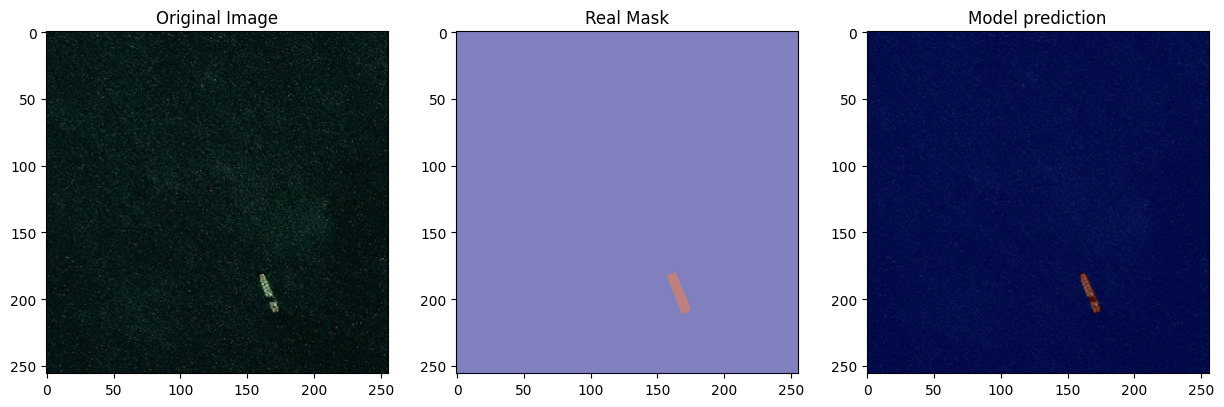

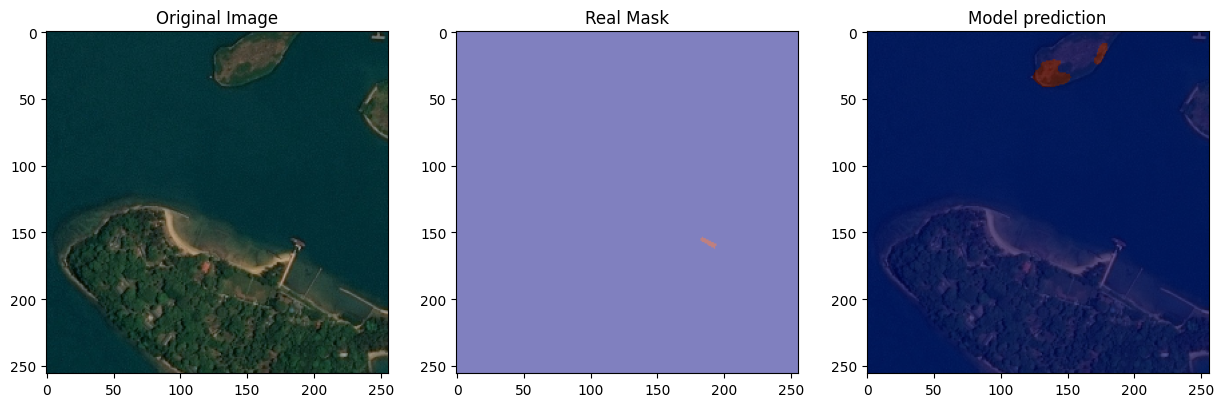

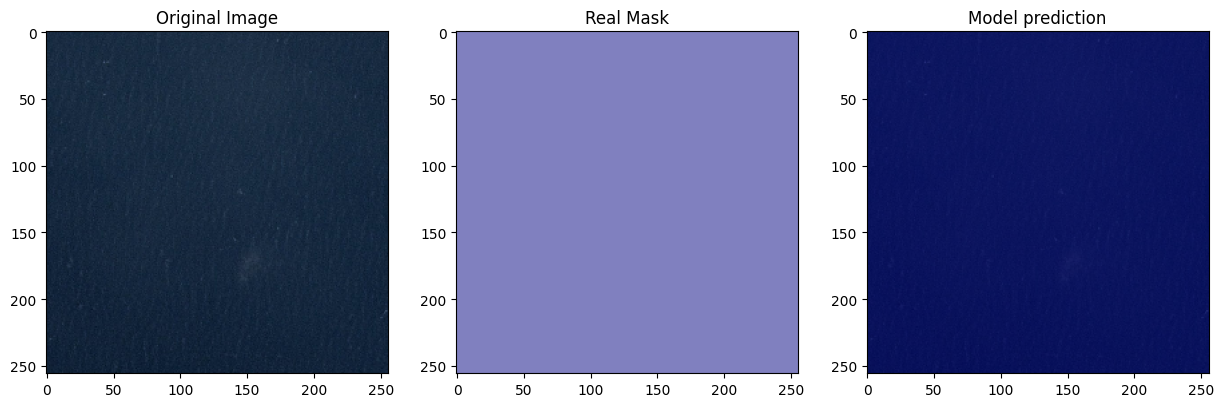

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import random 

random_index = random.randint(0, len(val_generator) - 1)
images, true_masks = val_generator[random_index]

predictions = model.predict(images)

for i in range(3):
    plt.figure(figsize = (15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(images[i])

    plt.subplot(1, 3, 2)
    plt.title("Real Mask")
    plt.imshow(true_masks[i].squeeze(), cmap = "jet", alpha = 0.5)

    plt.subplot(1, 3, 3)
    plt.title("Model prediction")
    plt.imshow(images[i])

    pred_mask = (predictions[i].squeeze() > 0.525).astype(np.uint8)
    plt.imshow(pred_mask, cmap = "jet", alpha = 0.5)

    plt.show()

In [66]:
from sklearn.metrics import classification_report

y_true =true_masks[0].squeeze().flatten()
y_pred = (predictions[0].squeeze() > 0.525).astype(np.uint8).flatten()

print(classification_report(y_true, y_pred, target_names = ["Background", "Ship"]))

              precision    recall  f1-score   support

  Background       1.00      1.00      1.00     65304
        Ship       0.98      0.79      0.88       232

    accuracy                           1.00     65536
   macro avg       0.99      0.90      0.94     65536
weighted avg       1.00      1.00      1.00     65536

